# Hybrid XGBoost + LSTM Forecasting

D8 Solutions - Carlota

This notebook builds two hybrid models using the same project framework as the
XGBoost and LSTM notebooks:

1. Parallel hybrid: weighted average of XGBoost and LSTM predictions.
2. Sequential hybrid: LSTM prediction plus an XGBoost residual correction.

It reuses the LSTM outputs already generated by Carlota's notebook, then trains
XGBoost backtest/future predictions so both models can be compared on the same
SKU-months.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "xgboost is required. In Colab run: %pip install -q xgboost"
    ) from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 1. Set paths

Update these paths to match your Drive. If all CSVs are in the same folder as
this notebook, keep the simple file names.



In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Employers Project/Analysis/sales_collision.csv"

LSTM_BACKTEST_PREDICTIONS_PATH = "/content/drive/MyDrive/Colab Notebooks/Employers Project/Analysis/LSTM (Carlota)/LSTM Results/lstm_backtest_predictions.csv"
LSTM_FORECASTS_18M_PATH = "/content/drive/MyDrive/Colab Notebooks/Employers Project/Analysis/LSTM (Carlota)/LSTM Results/lstm_forecasts_18m.csv"
LSTM_SKU_WMAPE_PATH = "/content/drive/MyDrive/Colab Notebooks/Employers Project/Analysis/LSTM (Carlota)/LSTM Results/lstm_sku_wmape.csv"

OUTPUT_DIR = "."

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load data and LSTM outputs



In [ ]:
sales_collision = pd.read_csv(DATA_PATH)
sales_collision["month"] = pd.to_datetime(sales_collision["month"])
sales_collision["demand"] = pd.to_numeric(sales_collision["demand"], errors="coerce").fillna(0.0)
sales_collision = sales_collision.sort_values(["sku_id", "month"]).reset_index(drop=True)

lstm_backtest = pd.read_csv(LSTM_BACKTEST_PREDICTIONS_PATH)
lstm_backtest["month"] = pd.to_datetime(lstm_backtest["month"])

lstm_future = pd.read_csv(LSTM_FORECASTS_18M_PATH)
lstm_future["month"] = pd.to_datetime(lstm_future["month"])

lstm_sku_wmape = pd.read_csv(LSTM_SKU_WMAPE_PATH)

print(f"sales_collision rows: {len(sales_collision):,}")
print(f"SKUs: {sales_collision['sku_id'].nunique():,}")
print(f"LSTM backtest rows: {len(lstm_backtest):,}")
print(f"LSTM future rows: {len(lstm_future):,}")

display(sales_collision.groupby("sku_id")["demand_type"].first().value_counts())

sales_collision rows: 180,422
SKUs: 8,097
LSTM backtest rows: 56,435
LSTM future rows: 145,746


,count
demand_type,
Intermittent,6593
Smooth,972
Lumpy,381
Erratic,124
No demand observed,27


## 3. Shared constants and metric



In [ ]:
FORECAST_LAG = 3
N_FORECAST = 18
MIN_TRAIN = 100


def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom


def safe_clip(values):
    return np.asarray(values, dtype=float).clip(min=0)

## 4. Recreate XGBoost features

These features mirror David's XGBoost notebook so the hybrid model stays aligned
with the group approach.



In [ ]:
total_demand_by_sku = sales_collision.groupby("sku_id")["demand"].sum().rename("total_demand_sku")
sales_collision = sales_collision.drop(columns=["total_demand_sku"], errors="ignore")
sales_collision = sales_collision.merge(total_demand_by_sku, on="sku_id", how="left")

threshold_20 = sales_collision["total_demand_sku"].quantile(0.80)
threshold_5 = sales_collision["total_demand_sku"].quantile(0.95)
sales_collision["is_top20pct"] = (sales_collision["total_demand_sku"] >= threshold_20).astype(int)
sales_collision["is_top5pct"] = (sales_collision["total_demand_sku"] >= threshold_5).astype(int)

df = sales_collision[["sku_id", "month", "demand", "demand_type", "total_demand_sku", "is_top20pct", "is_top5pct"]].copy()
df = df.sort_values(["sku_id", "month"]).reset_index(drop=True)


def engineer_features(data):
    data = data.sort_values(["sku_id", "month"]).copy()
    g = data.groupby("sku_id")["demand"]

    for lag in [3, 4, 5, 6, 9, 12, 15]:
        data[f"lag_{lag}m"] = g.shift(lag)

    for w in [3, 6, 12]:
        data[f"roll_mean_{w}m"] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).mean())
        data[f"roll_std_{w}m"] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).std().fillna(0))
        data[f"roll_max_{w}m"] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).max())

    data["_is_zero"] = (data["demand"] == 0).astype(float)
    gz = data.groupby("sku_id")["_is_zero"]
    data["zero_share_6m"] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(6, min_periods=1).mean())
    data["zero_share_12m"] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(12, min_periods=1).mean())
    data = data.drop(columns=["_is_zero"])

    data["month_of_year"] = data["month"].dt.month
    data["quarter"] = data["month"].dt.quarter
    data["year"] = data["month"].dt.year

    first_sale = data[data["demand"] > 0].groupby("sku_id")["month"].min().rename("_first_sale")
    data = data.merge(first_sale, on="sku_id", how="left")
    data["sku_age_months"] = (
        (data["month"].dt.year - data["_first_sale"].dt.year) * 12
        + (data["month"].dt.month - data["_first_sale"].dt.month)
    ).clip(lower=0).fillna(0)
    data["is_new_sku"] = (data["sku_age_months"] < 6).astype(int)
    data = data.drop(columns=["_first_sale"])

    return data


FEATURE_COLS = (
    [f"lag_{lag}m" for lag in [3, 4, 5, 6, 9, 12, 15]]
    + [f"roll_mean_{w}m" for w in [3, 6, 12]]
    + [f"roll_std_{w}m" for w in [3, 6, 12]]
    + [f"roll_max_{w}m" for w in [3, 6, 12]]
    + [
        "zero_share_6m",
        "zero_share_12m",
        "month_of_year",
        "quarter",
        "year",
        "sku_age_months",
        "is_new_sku",
    ]
)

df_features = engineer_features(df)
print(f"Feature dataframe: {df_features.shape}")

Feature dataframe: (180422, 30)


## 5. Train XGBoost rolling-origin backtest



In [ ]:
def make_xgb_model():
    return XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )


def rolling_backtest_xgb(data, demand_type):
    subset = data[data["demand_type"] == demand_type].sort_values("month").copy()
    months = sorted(pd.to_datetime(subset["month"].unique()))
    month_set = set(months)
    parts = []
    metrics = []

    for cutoff in months:
        pred_month = cutoff + pd.DateOffset(months=FORECAST_LAG)
        if pred_month not in month_set:
            continue

        train = subset[subset["month"] <= cutoff].dropna(subset=FEATURE_COLS)
        test = subset[subset["month"] == pred_month].dropna(subset=FEATURE_COLS)

        if len(train) < MIN_TRAIN or len(test) == 0:
            continue

        model = make_xgb_model()
        model.fit(train[FEATURE_COLS], train["demand"], verbose=False)
        pred = safe_clip(model.predict(test[FEATURE_COLS]))

        fold = test[["sku_id", "month", "demand", "demand_type"]].copy()
        fold["xgb_pred"] = pred
        fold["cutoff"] = cutoff
        fold["pred_month"] = pred_month
        parts.append(fold)

        metrics.append({
            "demand_type": demand_type,
            "cutoff": cutoff,
            "pred_month": pred_month,
            "xgb_wmape": wmape(fold["demand"], fold["xgb_pred"]),
            "n_train": len(train),
            "n_test": len(test),
        })

        print(f"{demand_type:<12} cutoff={cutoff.strftime('%Y-%m')} pred={pred_month.strftime('%Y-%m')} XGB WMAPE={metrics[-1]['xgb_wmape']:.3f}")

    pred_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    metrics_df = pd.DataFrame(metrics)
    return pred_df, metrics_df


DEMAND_TYPES = [
    dt for dt in df_features["demand_type"].dropna().unique()
    if dt != "No demand observed"
]

xgb_parts = []
xgb_metric_parts = []

for dt in DEMAND_TYPES:
    print("\n" + "=" * 70)
    print(f"XGBoost rolling backtest for {dt}")
    pred_df, metrics_df = rolling_backtest_xgb(df_features, dt)
    if not pred_df.empty:
        xgb_parts.append(pred_df)
        xgb_metric_parts.append(metrics_df)

xgb_backtest = pd.concat(xgb_parts, ignore_index=True)
xgb_backtest_metrics = pd.concat(xgb_metric_parts, ignore_index=True)

print(f"\nXGBoost backtest rows: {len(xgb_backtest):,}")
display(xgb_backtest.head())


XGBoost rolling backtest for Lumpy
Lumpy        cutoff=2025-04 pred=2025-07 XGB WMAPE=1.502
Lumpy        cutoff=2025-05 pred=2025-08 XGB WMAPE=1.702
Lumpy        cutoff=2025-06 pred=2025-09 XGB WMAPE=1.570
Lumpy        cutoff=2025-07 pred=2025-10 XGB WMAPE=1.299
Lumpy        cutoff=2025-08 pred=2025-11 XGB WMAPE=0.940
Lumpy        cutoff=2025-09 pred=2025-12 XGB WMAPE=1.219
Lumpy        cutoff=2025-10 pred=2026-01 XGB WMAPE=1.239
Lumpy        cutoff=2025-11 pred=2026-02 XGB WMAPE=1.299
Lumpy        cutoff=2025-12 pred=2026-03 XGB WMAPE=1.285
Lumpy        cutoff=2026-01 pred=2026-04 XGB WMAPE=1.325

XGBoost rolling backtest for Intermittent
Intermittent cutoff=2025-04 pred=2025-07 XGB WMAPE=1.129
Intermittent cutoff=2025-05 pred=2025-08 XGB WMAPE=1.256
Intermittent cutoff=2025-06 pred=2025-09 XGB WMAPE=1.399
Intermittent cutoff=2025-07 pred=2025-10 XGB WMAPE=1.224
Intermittent cutoff=2025-08 pred=2025-11 XGB WMAPE=1.260
Intermittent cutoff=2025-09 pred=2025-12 XGB WMAPE=1.251
Intermitt

,sku_id,month,demand,demand_type,xgb_pred,cutoff,pred_month
0,84730M69RA0000,2025-07-01,4.0,Lumpy,1.137851,2025-04-01,2025-07-01
1,83831M76M00000,2025-07-01,0.0,Lumpy,1.071118,2025-04-01,2025-07-01
2,75110M76T60R3F,2025-07-01,1.0,Lumpy,0.757736,2025-04-01,2025-07-01
3,083313124A000,2025-07-01,0.0,Lumpy,0.757736,2025-04-01,2025-07-01
4,72321M76T00000,2025-07-01,2.0,Lumpy,0.698786,2025-04-01,2025-07-01


## 6. Align XGBoost and LSTM backtest predictions



In [ ]:
lstm_bt = lstm_backtest.rename(columns={
    "actual": "actual",
    "lstm_pred": "lstm_pred",
    "baseline": "baseline",
})

aligned = (
    lstm_bt[["sku_id", "month", "actual", "demand_type", "lstm_pred", "baseline"]]
    .merge(
        xgb_backtest[["sku_id", "month", "xgb_pred"]],
        on=["sku_id", "month"],
        how="inner",
    )
)

sku_meta = sales_collision[["sku_id", "total_demand_sku", "is_top20pct", "is_top5pct"]].drop_duplicates()
aligned = aligned.merge(sku_meta, on="sku_id", how="left")

print(f"Aligned backtest rows: {len(aligned):,}")
print(f"Aligned SKUs: {aligned['sku_id'].nunique():,}")
display(aligned.head())

Aligned backtest rows: 56,435
Aligned SKUs: 6,654


,sku_id,month,actual,demand_type,lstm_pred,baseline,xgb_pred,total_demand_sku,is_top20pct,is_top5pct
0,015500612A000,2025-08-01,0.0,Lumpy,0.227797,0.000000,0.088465,8.0,0,0
1,083313124A000,2025-08-01,0.0,Lumpy,0.099145,0.000000,0.246046,4.0,0,0
2,0911912007000,2025-08-01,0.0,Lumpy,0.611039,8.000000,10.003213,157.0,1,1
3,0915912057000,2025-08-01,4.0,Lumpy,3.078460,11.666667,23.134335,248.0,1,1
4,0915912L02000,2025-08-01,0.0,Lumpy,0.180725,0.000000,0.513217,9.0,0,0


## 7. Parallel hybrid

The parallel hybrid combines independent XGBoost and LSTM predictions:

`parallel = alpha * XGBoost + (1 - alpha) * LSTM`

Alpha is selected separately for each demand type by minimizing backtest WMAPE.



In [ ]:
alpha_grid = np.round(np.arange(0, 1.01, 0.05), 2)
parallel_alpha_rows = []
parallel_parts = []

for dt, group in aligned.groupby("demand_type"):
    best = None
    for alpha in alpha_grid:
        pred = alpha * group["xgb_pred"].values + (1 - alpha) * group["lstm_pred"].values
        score = wmape(group["actual"].values, pred)
        row = {"demand_type": dt, "alpha_xgb": alpha, "parallel_wmape": score}
        if best is None or score < best["parallel_wmape"]:
            best = row

    parallel_alpha_rows.append(best)
    part = group.copy()
    part["alpha_xgb"] = best["alpha_xgb"]
    part["parallel_pred"] = safe_clip(
        best["alpha_xgb"] * part["xgb_pred"].values
        + (1 - best["alpha_xgb"]) * part["lstm_pred"].values
    )
    parallel_parts.append(part)

parallel_alpha = pd.DataFrame(parallel_alpha_rows)
parallel_backtest = pd.concat(parallel_parts, ignore_index=True)

display(parallel_alpha)

,demand_type,alpha_xgb,parallel_wmape
0,Erratic,0.45,0.710616
1,Intermittent,0.00,1.139698
2,Lumpy,0.00,1.017592
3,Smooth,0.55,0.459452


## 8. Sequential hybrid

The sequential hybrid uses LSTM as the base prediction, then trains XGBoost to
correct the residual:

`residual = actual - LSTM`

`sequential = LSTM + XGBoost_residual_prediction`

This tests whether XGBoost can learn systematic errors left by the LSTM.



In [ ]:
residual_feature_cols = FEATURE_COLS + ["lstm_pred", "xgb_pred"]

residual_data = (
    aligned
    .merge(
        df_features[["sku_id", "month"] + FEATURE_COLS],
        on=["sku_id", "month"],
        how="left",
    )
    .dropna(subset=FEATURE_COLS + ["lstm_pred", "xgb_pred"])
    .copy()
)

residual_data["residual"] = residual_data["actual"] - residual_data["lstm_pred"]


def sequential_residual_backtest(data, demand_type):
    subset = data[data["demand_type"] == demand_type].sort_values("month").copy()
    months = sorted(pd.to_datetime(subset["month"].unique()))
    parts = []

    for pred_month in months:
        train = subset[subset["month"] < pred_month].dropna(subset=residual_feature_cols)
        test = subset[subset["month"] == pred_month].dropna(subset=residual_feature_cols)

        if len(train) < MIN_TRAIN or len(test) == 0:
            continue

        model = XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
        )
        model.fit(train[residual_feature_cols], train["residual"], verbose=False)
        residual_pred = model.predict(test[residual_feature_cols])

        fold = test[["sku_id", "month", "actual", "demand_type", "lstm_pred", "xgb_pred", "baseline"]].copy()
        fold["residual_pred"] = residual_pred
        fold["sequential_pred"] = safe_clip(fold["lstm_pred"].values + residual_pred)
        parts.append(fold)

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


seq_parts = []
for dt in DEMAND_TYPES:
    part = sequential_residual_backtest(residual_data, dt)
    if not part.empty:
        seq_parts.append(part)

sequential_backtest = pd.concat(seq_parts, ignore_index=True)
print(f"Sequential backtest rows: {len(sequential_backtest):,}")
display(sequential_backtest.head())

Sequential backtest rows: 52,037


,sku_id,month,actual,demand_type,lstm_pred,xgb_pred,baseline,residual_pred,sequential_pred
0,73310M68P61C8J,2025-09-01,1.0,Lumpy,0.414520,0.705088,0.333333,-0.094518,0.320001
1,73412M53M10U3J,2025-09-01,0.0,Lumpy,0.520480,0.000000,3.666667,-0.224508,0.295973
2,72321M76T00000,2025-09-01,1.0,Lumpy,0.645388,1.670249,1.666667,1.089452,1.734840
3,7281352R00000,2025-09-01,0.0,Lumpy,0.487338,1.082558,0.333333,-0.161681,0.325657
4,73430658205PK,2025-09-01,0.0,Lumpy,0.259238,0.605452,0.000000,0.012250,0.271488


## 9. Backtest summary



In [ ]:
def summarize_model(group, pred_col):
    return wmape(group["actual"].values, group[pred_col].values)


summary_rows = []
for dt, group in aligned.groupby("demand_type"):
    row = {
        "demand_type": dt,
        "n_skus": group["sku_id"].nunique(),
        "baseline_wmape": summarize_model(group, "baseline"),
        "lstm_wmape": summarize_model(group, "lstm_pred"),
        "xgb_wmape": summarize_model(group, "xgb_pred"),
        "parallel_wmape": summarize_model(parallel_backtest[parallel_backtest["demand_type"] == dt], "parallel_pred"),
    }
    seq_group = sequential_backtest[sequential_backtest["demand_type"] == dt]
    row["sequential_wmape"] = summarize_model(seq_group, "sequential_pred") if not seq_group.empty else np.nan
    summary_rows.append(row)

hybrid_summary = pd.DataFrame(summary_rows)
for col in ["lstm_wmape", "xgb_wmape", "parallel_wmape", "sequential_wmape"]:
    hybrid_summary[f"{col}_improvement_vs_baseline_pct"] = (
        (hybrid_summary["baseline_wmape"] - hybrid_summary[col]) / hybrid_summary["baseline_wmape"] * 100
    )

display(hybrid_summary)

,demand_type,n_skus,baseline_wmape,lstm_wmape,xgb_wmape,parallel_wmape,sequential_wmape,lstm_wmape_improvement_vs_baseline_pct,xgb_wmape_improvement_vs_baseline_pct,parallel_wmape_improvement_vs_baseline_pct,sequential_wmape_improvement_vs_baseline_pct
0,Erratic,109,0.744700,0.768977,0.773833,0.710616,0.877454,-3.259916,-3.912038,4.576989,-17.826440
1,Intermittent,5281,1.226114,1.139698,1.284772,1.139698,1.231469,7.047927,-4.784091,7.047927,-0.436744
2,Lumpy,352,1.210178,1.017592,1.283510,1.017592,1.150015,15.913855,-6.059552,15.913855,4.971398
3,Smooth,912,0.468357,0.495843,0.475346,0.459452,0.484130,-5.868471,-1.492198,1.901395,-3.367635


## 10. WMAPE < 70% analysis



In [ ]:
parallel_sku = (
    parallel_backtest
    .groupby(["sku_id", "demand_type"])
    .apply(lambda g: pd.Series({
        "actual_total": g["actual"].sum(),
        "parallel_wmape": wmape(g["actual"], g["parallel_pred"]),
        "lstm_wmape": wmape(g["actual"], g["lstm_pred"]),
        "xgb_wmape": wmape(g["actual"], g["xgb_pred"]),
        "baseline_wmape": wmape(g["actual"], g["baseline"]),
    }))
    .reset_index()
    .merge(sku_meta, on="sku_id", how="left")
)

seq_sku = (
    sequential_backtest
    .groupby(["sku_id", "demand_type"])
    .apply(lambda g: pd.Series({
        "actual_total": g["actual"].sum(),
        "sequential_wmape": wmape(g["actual"], g["sequential_pred"]),
    }))
    .reset_index()
    .merge(sku_meta, on="sku_id", how="left")
)


def lt70_table(sku_df, model_col):
    valid = sku_df.dropna(subset=[model_col]).copy()
    valid = valid[valid["actual_total"] > 0]
    return (
        valid
        .assign(wmape_lt70=valid[model_col] < 0.70)
        .groupby(["demand_type", "is_top20pct"], as_index=False)
        .agg(
            n_skus=("sku_id", "nunique"),
            n_wmape_lt70=("wmape_lt70", "sum"),
            median_wmape=(model_col, "median"),
        )
        .assign(pct_wmape_lt70=lambda x: (x["n_wmape_lt70"] / x["n_skus"] * 100).round(1))
    )


parallel_lt70 = lt70_table(parallel_sku, "parallel_wmape")
parallel_lt70["model"] = "parallel_hybrid"

sequential_lt70 = lt70_table(seq_sku, "sequential_wmape")
sequential_lt70["model"] = "sequential_hybrid"

hybrid_lt70 = pd.concat([parallel_lt70, sequential_lt70], ignore_index=True)
display(hybrid_lt70)

,demand_type,is_top20pct,n_skus,n_wmape_lt70,median_wmape,pct_wmape_lt70,model
0,Erratic,0,2,2,0.555047,100.0,parallel_hybrid
1,Erratic,1,107,60,0.659759,56.1,parallel_hybrid
2,Intermittent,0,3040,61,1.264274,2.0,parallel_hybrid
3,Intermittent,1,206,20,0.833632,9.7,parallel_hybrid
4,Lumpy,0,193,5,1.261855,2.6,parallel_hybrid
5,Lumpy,1,91,9,0.919686,9.9,parallel_hybrid
6,Smooth,0,14,10,0.597792,71.4,parallel_hybrid
7,Smooth,1,898,753,0.497664,83.9,parallel_hybrid
8,Erratic,0,2,1,0.741631,50.0,sequential_hybrid
9,Erratic,1,107,39,0.760691,36.4,sequential_hybrid


## 11. Future XGBoost forecast



In [ ]:
def train_final_xgb_models(data):
    models = {}
    for dt in DEMAND_TYPES:
        subset = data[data["demand_type"] == dt].dropna(subset=FEATURE_COLS)
        if len(subset) < MIN_TRAIN:
            continue
        model = make_xgb_model()
        model.fit(subset[FEATURE_COLS], subset["demand"], verbose=False)
        models[dt] = model
    return models


def generate_xgb_future(data, models):
    first_sale = data[data["demand"] > 0].groupby("sku_id")["month"].min().rename("_first_sale")
    pool = (
        data[["sku_id", "month", "demand", "demand_type"]]
        .sort_values(["sku_id", "month"])
        .groupby("sku_id")
        .tail(16)
        .reset_index(drop=True)
        .merge(first_sale, on="sku_id", how="left")
    )

    last_month = data["month"].max()
    all_forecasts = []

    for h in range(1, N_FORECAST + 1):
        target_month = last_month + pd.DateOffset(months=h)
        sku_meta_future = pool[["sku_id", "demand_type", "_first_sale"]].drop_duplicates()
        future_rows = sku_meta_future.assign(month=target_month, demand=np.nan)
        extended = pd.concat([pool, future_rows], ignore_index=True).sort_values(["sku_id", "month"]).copy()

        g = extended.groupby("sku_id")["demand"]
        for lag in [3, 4, 5, 6, 9, 12, 15]:
            extended[f"lag_{lag}m"] = g.shift(lag)
        for w in [3, 6, 12]:
            extended[f"roll_mean_{w}m"] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).mean())
            extended[f"roll_std_{w}m"] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).std().fillna(0))
            extended[f"roll_max_{w}m"] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).max())

        extended["_is_zero"] = (extended["demand"].fillna(0) == 0).astype(float)
        gz = extended.groupby("sku_id")["_is_zero"]
        extended["zero_share_6m"] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(6, min_periods=1).mean())
        extended["zero_share_12m"] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(12, min_periods=1).mean())

        extended["month_of_year"] = extended["month"].dt.month
        extended["quarter"] = extended["month"].dt.quarter
        extended["year"] = extended["month"].dt.year
        extended["sku_age_months"] = (
            (extended["month"].dt.year - extended["_first_sale"].dt.year) * 12
            + (extended["month"].dt.month - extended["_first_sale"].dt.month)
        ).clip(lower=0).fillna(0)
        extended["is_new_sku"] = (extended["sku_age_months"] < 6).astype(int)
        extended = extended.drop(columns=["_is_zero"])

        target_rows = extended[extended["month"] == target_month].copy()
        fc_parts = []
        for dt, model in models.items():
            rows_dt = target_rows[target_rows["demand_type"] == dt].dropna(subset=FEATURE_COLS)
            if rows_dt.empty:
                continue
            preds = safe_clip(model.predict(rows_dt[FEATURE_COLS]))
            out = rows_dt[["sku_id", "month", "demand_type", "_first_sale"]].copy()
            out["xgb_forecast"] = preds
            out["demand"] = preds
            fc_parts.append(out)

        if fc_parts:
            fc_month = pd.concat(fc_parts, ignore_index=True)
        else:
            fc_month = pd.DataFrame(columns=["sku_id", "month", "demand_type", "_first_sale", "xgb_forecast", "demand"])

        fc_month["horizon"] = h
        all_forecasts.append(fc_month[["sku_id", "month", "horizon", "demand_type", "xgb_forecast"]])

        pool = pd.concat(
            [pool, fc_month[["sku_id", "month", "demand", "demand_type", "_first_sale"]]],
            ignore_index=True,
        )

        print(f"h={h:2d} {target_month.strftime('%Y-%m')} XGB forecasts={len(fc_month):,}")

    xgb_future = pd.concat(all_forecasts, ignore_index=True)
    return xgb_future


xgb_final_models = train_final_xgb_models(df_features)
xgb_future = generate_xgb_future(df, xgb_final_models)
display(xgb_future.head())

h= 1 2026-05 XGB forecasts=6,787
h= 2 2026-06 XGB forecasts=6,787
h= 3 2026-07 XGB forecasts=6,787
h= 4 2026-08 XGB forecasts=6,787
h= 5 2026-09 XGB forecasts=6,787
h= 6 2026-10 XGB forecasts=6,787
h= 7 2026-11 XGB forecasts=6,787
h= 8 2026-12 XGB forecasts=6,787
h= 9 2027-01 XGB forecasts=6,787
h=10 2027-02 XGB forecasts=6,787
h=11 2027-03 XGB forecasts=6,787
h=12 2027-04 XGB forecasts=6,787
h=13 2027-05 XGB forecasts=6,787
h=14 2027-06 XGB forecasts=6,787
h=15 2027-07 XGB forecasts=6,787
h=16 2027-08 XGB forecasts=6,787
h=17 2027-09 XGB forecasts=6,787
h=18 2027-10 XGB forecasts=6,787


,sku_id,month,horizon,demand_type,xgb_forecast
0,015500612A000,2026-05-01,1,Lumpy,0.309600
1,02142M0508A000,2026-05-01,1,Lumpy,0.301181
2,083313124A000,2026-05-01,1,Lumpy,0.297668
3,0910010275000,2026-05-01,1,Lumpy,0.301181
4,0911610173000,2026-05-01,1,Lumpy,0.316097


## 12. Future hybrid forecasts



In [ ]:
lstm_future_renamed = lstm_future.rename(columns={"forecast": "lstm_forecast"})

future_aligned = (
    lstm_future_renamed[["sku_id", "month", "horizon", "demand_type", "lstm_forecast", "forecast_source"]]
    .merge(
        xgb_future[["sku_id", "month", "xgb_forecast"]],
        on=["sku_id", "month"],
        how="left",
    )
    .merge(sku_meta, on="sku_id", how="left")
)

future_aligned["xgb_forecast"] = future_aligned["xgb_forecast"].fillna(0)
future_aligned = future_aligned.merge(parallel_alpha, on="demand_type", how="left")
future_aligned["alpha_xgb"] = future_aligned["alpha_xgb"].fillna(0)
future_aligned["parallel_forecast"] = safe_clip(
    future_aligned["alpha_xgb"].values * future_aligned["xgb_forecast"].values
    + (1 - future_aligned["alpha_xgb"].values) * future_aligned["lstm_forecast"].values
)

# Final residual models for future sequential correction.
residual_models = {}
for dt in DEMAND_TYPES:
    subset = residual_data[residual_data["demand_type"] == dt].dropna(subset=residual_feature_cols)
    if len(subset) < MIN_TRAIN:
        continue
    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )
    model.fit(subset[residual_feature_cols], subset["residual"], verbose=False)
    residual_models[dt] = model

# Build future residual features using XGB-style future feature table.
future_residual_features = future_aligned.copy()
future_residual_features = future_residual_features.rename(columns={
    "lstm_forecast": "lstm_pred",
    "xgb_forecast": "xgb_pred",
})

# For future residual correction, reuse available future XGB feature columns by
# recomputing them on a pool where future LSTM demand is used as the demand path.
future_pool = pd.concat(
    [
        df[["sku_id", "month", "demand", "demand_type", "total_demand_sku", "is_top20pct", "is_top5pct"]],
        future_aligned[["sku_id", "month", "demand_type", "total_demand_sku", "is_top20pct", "is_top5pct"]]
        .assign(demand=future_aligned["lstm_forecast"].values),
    ],
    ignore_index=True,
)
future_feature_table = engineer_features(future_pool)
future_feature_table = future_feature_table[future_feature_table["month"] > df["month"].max()]

future_residual_features = future_residual_features.merge(
    future_feature_table[["sku_id", "month"] + FEATURE_COLS],
    on=["sku_id", "month"],
    how="left",
)

future_residual_features["sequential_forecast"] = future_residual_features["lstm_pred"]

for dt, model in residual_models.items():
    mask = future_residual_features["demand_type"] == dt
    rows = future_residual_features.loc[mask].dropna(subset=residual_feature_cols)
    if rows.empty:
        continue
    residual_pred = model.predict(rows[residual_feature_cols])
    future_residual_features.loc[rows.index, "sequential_forecast"] = safe_clip(
        rows["lstm_pred"].values + residual_pred
    )

hybrid_future = future_residual_features[[
    "sku_id",
    "month",
    "horizon",
    "demand_type",
    "lstm_pred",
    "xgb_pred",
    "parallel_forecast",
    "sequential_forecast",
    "alpha_xgb",
    "forecast_source",
    "is_top20pct",
    "is_top5pct",
]].rename(columns={
    "lstm_pred": "lstm_forecast",
    "xgb_pred": "xgb_forecast",
})

display(hybrid_future.head())
print(hybrid_future.groupby("demand_type")[["parallel_forecast", "sequential_forecast"]].sum())

,sku_id,month,horizon,demand_type,lstm_forecast,xgb_forecast,parallel_forecast,sequential_forecast,alpha_xgb,forecast_source,is_top20pct,is_top5pct
0,015500612A000,2026-05-01,1,Lumpy,0.175170,0.309600,0.175170,0.410612,0.0,lstm,0,0
1,01550M0612A,2026-05-01,1,Intermittent,0.056309,0.096356,0.056309,0.084081,0.0,lstm,0,0
2,01550M0835A000,2026-05-01,1,Intermittent,0.500000,0.000000,0.500000,0.500000,0.0,rolling_avg_fallback,0,0
3,015511025A000,2026-05-01,1,Intermittent,0.032788,0.064519,0.032788,0.059486,0.0,lstm,0,0
4,021420412A000,2026-05-01,1,Intermittent,0.056309,0.095051,0.056309,0.084081,0.0,lstm,0,0


                    parallel_forecast  sequential_forecast
demand_type                                               
Erratic                   6914.247248          8313.650192
Intermittent             30664.589187         29817.500411
Lumpy                     4432.671656          7566.980994
No demand observed           0.000000             0.000000
Smooth                   81674.938499         93206.874833


## 13. Visualise hybrid forecasts



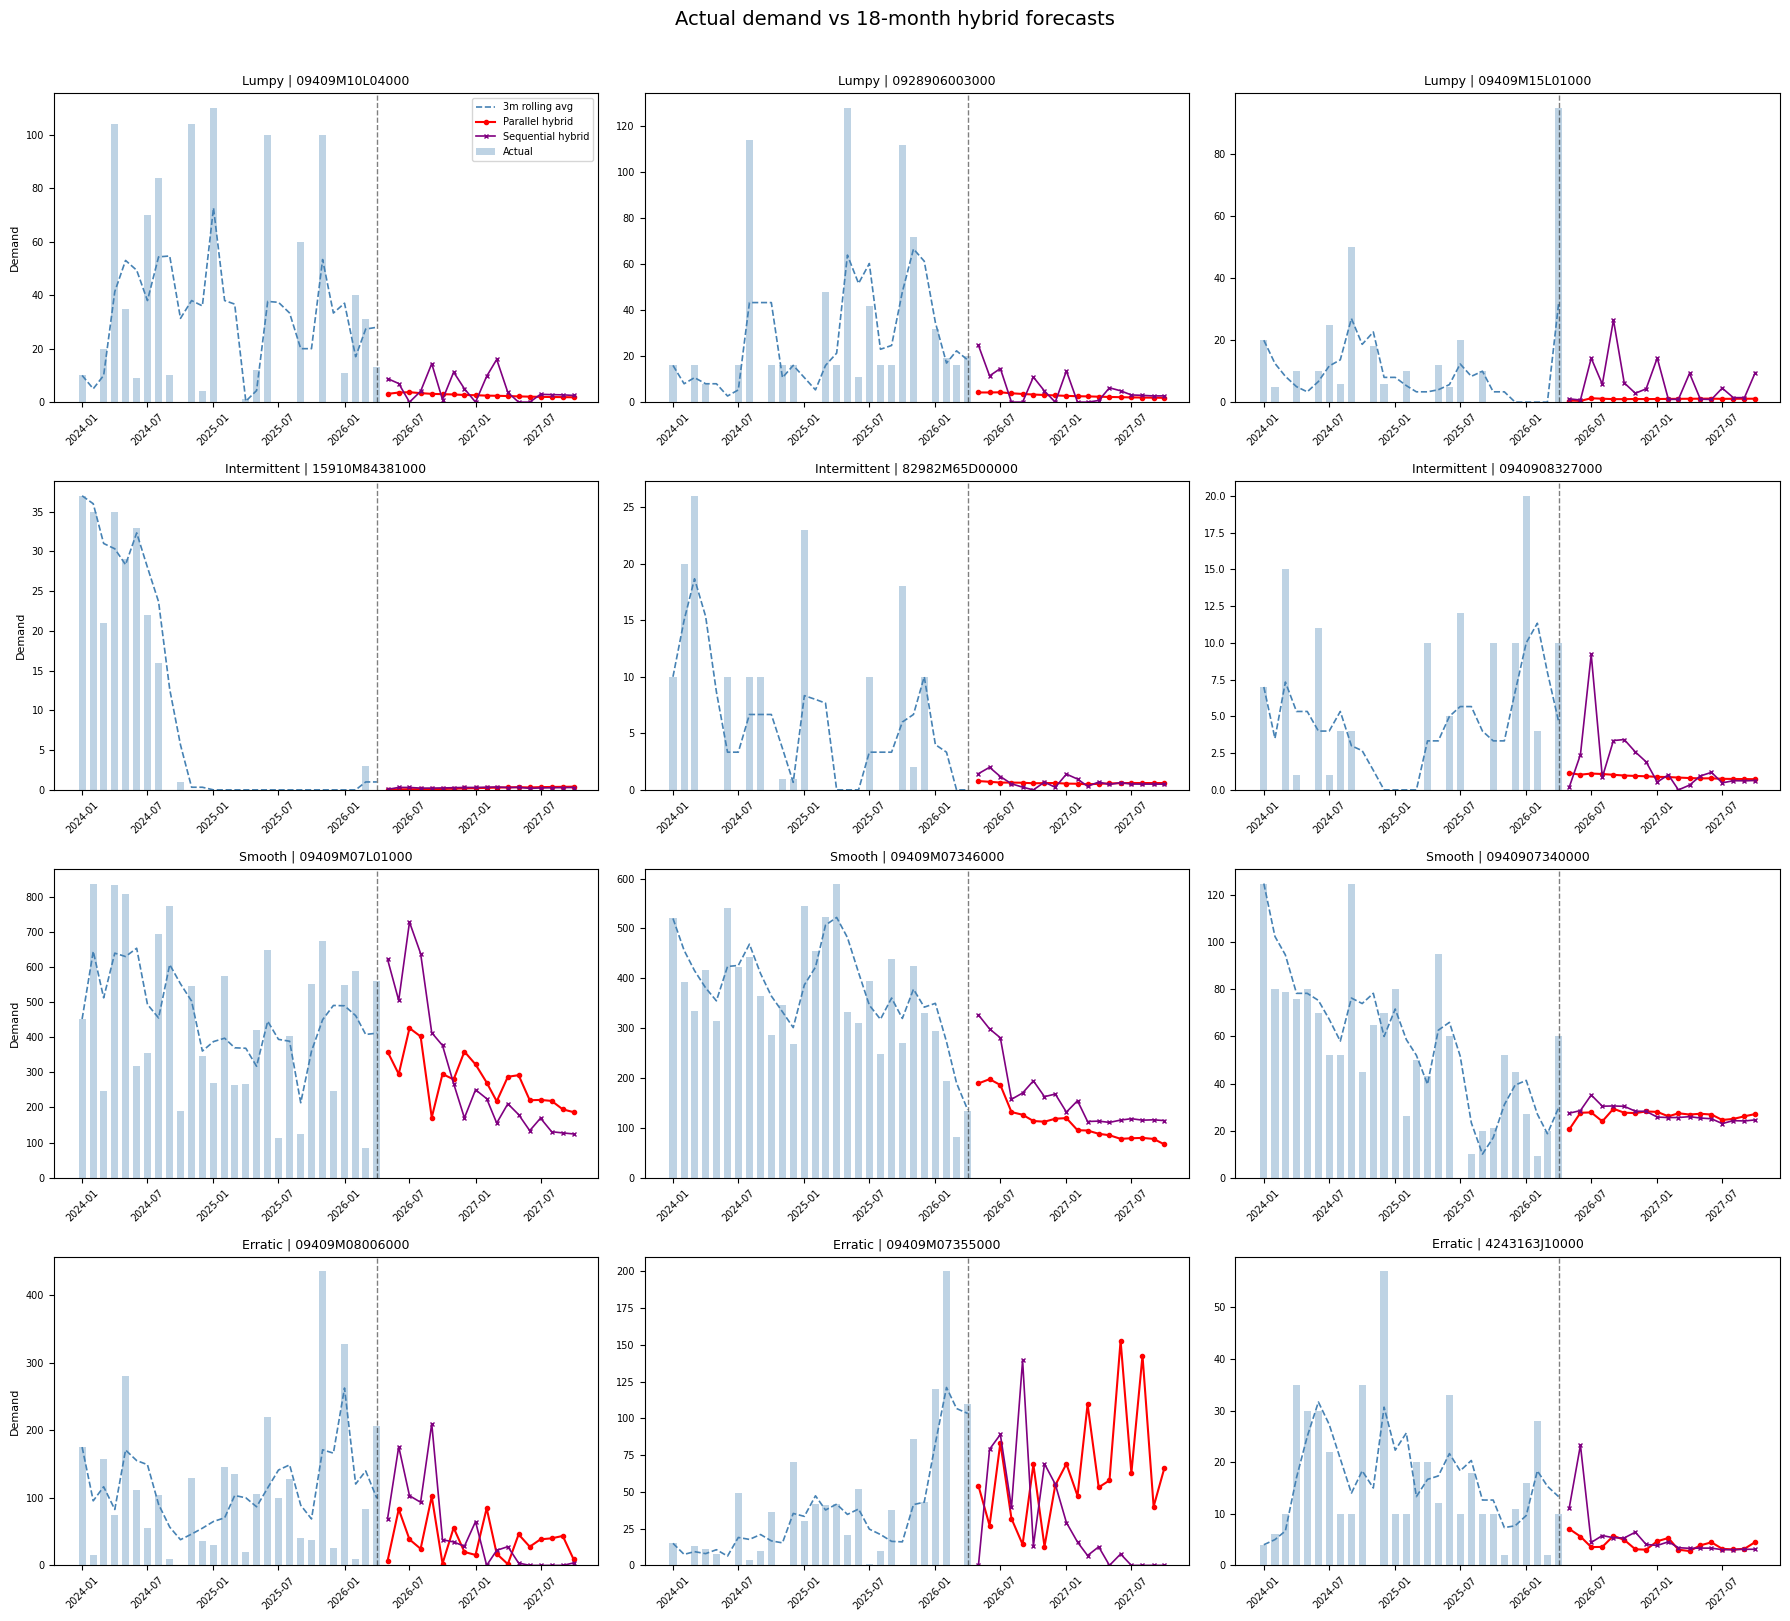

In [ ]:
N_SKUS_PER_TYPE = 3
plot_types = [dt for dt in DEMAND_TYPES if dt in df["demand_type"].unique()]

fig, axes = plt.subplots(len(plot_types), N_SKUS_PER_TYPE, figsize=(18, len(plot_types) * 4))
fig.suptitle("Actual demand vs 18-month hybrid forecasts", fontsize=14, y=1.01)

if len(plot_types) == 1:
    axes = np.array([axes])

last_month = df["month"].max()

for row_idx, dt in enumerate(plot_types):
    top_skus = (
        df[df["demand_type"] == dt]
        .groupby("sku_id")["demand"]
        .sum()
        .nlargest(N_SKUS_PER_TYPE)
        .index.tolist()
    )

    for col_idx, sku in enumerate(top_skus):
        ax = axes[row_idx][col_idx]
        actual = df[df["sku_id"] == sku][["month", "demand"]].sort_values("month").copy()
        actual["rolling_avg"] = actual["demand"].rolling(3, min_periods=1).mean()
        fc = hybrid_future[hybrid_future["sku_id"] == sku].sort_values("month")

        ax.bar(actual["month"], actual["demand"], color="steelblue", alpha=0.35, label="Actual", width=20)
        ax.plot(actual["month"], actual["rolling_avg"], color="steelblue", linestyle="--", linewidth=1.2, label="3m rolling avg")
        ax.plot(fc["month"], fc["parallel_forecast"], color="red", marker="o", markersize=3, linewidth=1.5, label="Parallel hybrid")
        ax.plot(fc["month"], fc["sequential_forecast"], color="purple", marker="x", markersize=3, linewidth=1.2, label="Sequential hybrid")
        ax.axvline(x=last_month, color="black", linestyle="--", linewidth=1, alpha=0.5)

        ax.set_title(f"{dt} | {sku}", fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        if col_idx == 0:
            ax.set_ylabel("Demand", fontsize=8)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_forecast_sample.png"), dpi=150, bbox_inches="tight")
plt.show()

## 14. Save outputs



In [ ]:
hybrid_summary.to_csv(os.path.join(OUTPUT_DIR, "hybrid_wmape_summary.csv"), index=False)
xgb_backtest.to_csv(os.path.join(OUTPUT_DIR, "hybrid_xgb_backtest_predictions.csv"), index=False)
parallel_backtest.to_csv(os.path.join(OUTPUT_DIR, "hybrid_parallel_backtest_predictions.csv"), index=False)
sequential_backtest.to_csv(os.path.join(OUTPUT_DIR, "hybrid_sequential_backtest_predictions.csv"), index=False)
parallel_sku.to_csv(os.path.join(OUTPUT_DIR, "hybrid_parallel_sku_wmape.csv"), index=False)
seq_sku.to_csv(os.path.join(OUTPUT_DIR, "hybrid_sequential_sku_wmape.csv"), index=False)
hybrid_lt70.to_csv(os.path.join(OUTPUT_DIR, "hybrid_wmape_lt70_analysis.csv"), index=False)
hybrid_future.to_csv(os.path.join(OUTPUT_DIR, "hybrid_forecasts_18m.csv"), index=False)
parallel_alpha.to_csv(os.path.join(OUTPUT_DIR, "hybrid_parallel_alpha_by_type.csv"), index=False)
xgb_backtest_metrics.to_csv(os.path.join(OUTPUT_DIR, "hybrid_xgb_backtest_metrics.csv"), index=False)

print("Saved hybrid outputs to:", OUTPUT_DIR)
for name in [
    "hybrid_wmape_summary.csv",
    "hybrid_forecasts_18m.csv",
    "hybrid_forecast_sample.png",
    "hybrid_wmape_lt70_analysis.csv",
    "hybrid_parallel_alpha_by_type.csv",
]:
    print("-", name)

Saved hybrid outputs to: .
- hybrid_wmape_summary.csv
- hybrid_forecasts_18m.csv
- hybrid_forecast_sample.png
- hybrid_wmape_lt70_analysis.csv
- hybrid_parallel_alpha_by_type.csv


## 15. Final interpretation helper



In [ ]:
print("=" * 80)
print("Hybrid XGBoost + LSTM Results Summary")
print("=" * 80)
print(f"Aligned backtest SKUs: {aligned['sku_id'].nunique():,}")
print(f"Future forecast rows: {len(hybrid_future):,}")
print("\nWMAPE summary by demand type:")
display(hybrid_summary)
print("\nParallel alpha by demand type:")
display(parallel_alpha)
print("\nWMAPE < 70% analysis:")
display(hybrid_lt70)
print("=" * 80)

Hybrid XGBoost + LSTM Results Summary
Aligned backtest SKUs: 6,654
Future forecast rows: 145,746

WMAPE summary by demand type:


,demand_type,n_skus,baseline_wmape,lstm_wmape,xgb_wmape,parallel_wmape,sequential_wmape,lstm_wmape_improvement_vs_baseline_pct,xgb_wmape_improvement_vs_baseline_pct,parallel_wmape_improvement_vs_baseline_pct,sequential_wmape_improvement_vs_baseline_pct
0,Erratic,109,0.744700,0.768977,0.773833,0.710616,0.877454,-3.259916,-3.912038,4.576989,-17.826440
1,Intermittent,5281,1.226114,1.139698,1.284772,1.139698,1.231469,7.047927,-4.784091,7.047927,-0.436744
2,Lumpy,352,1.210178,1.017592,1.283510,1.017592,1.150015,15.913855,-6.059552,15.913855,4.971398
3,Smooth,912,0.468357,0.495843,0.475346,0.459452,0.484130,-5.868471,-1.492198,1.901395,-3.367635



Parallel alpha by demand type:


,demand_type,alpha_xgb,parallel_wmape
0,Erratic,0.45,0.710616
1,Intermittent,0.00,1.139698
2,Lumpy,0.00,1.017592
3,Smooth,0.55,0.459452



WMAPE < 70% analysis:


,demand_type,is_top20pct,n_skus,n_wmape_lt70,median_wmape,pct_wmape_lt70,model
0,Erratic,0,2,2,0.555047,100.0,parallel_hybrid
1,Erratic,1,107,60,0.659759,56.1,parallel_hybrid
2,Intermittent,0,3040,61,1.264274,2.0,parallel_hybrid
3,Intermittent,1,206,20,0.833632,9.7,parallel_hybrid
4,Lumpy,0,193,5,1.261855,2.6,parallel_hybrid
5,Lumpy,1,91,9,0.919686,9.9,parallel_hybrid
6,Smooth,0,14,10,0.597792,71.4,parallel_hybrid
7,Smooth,1,898,753,0.497664,83.9,parallel_hybrid
8,Erratic,0,2,1,0.741631,50.0,sequential_hybrid
9,Erratic,1,107,39,0.760691,36.4,sequential_hybrid


In [ ]:
import glob

print("Current folder:", os.getcwd())
print("hybridfiles found:")
for f in glob.glob("/content/hybrid*"):
    print(f)

Current folder: /content
hybridfiles found:
/content/hybrid_parallel_alpha_by_type.csv
/content/hybrid_xgb_backtest_predictions.csv
/content/hybrid_forecasts_18m.csv
/content/hybrid_parallel_sku_wmape.csv
/content/hybrid_wmape_summary.csv
/content/hybrid_parallel_backtest_predictions.csv
/content/hybrid_wmape_lt70_analysis.csv
/content/hybrid_forecast_sample.png
/content/hybrid_sequential_sku_wmape.csv
/content/hybrid_xgb_backtest_metrics.csv
/content/hybrid_sequential_backtest_predictions.csv


In [ ]:
from google.colab import files

for f in glob.glob("/content/hybrid*"):
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>